---
Phase 2-8: 實用訓練技巧
---

讓模型從「能跑」到「跑得好」的關鍵技巧。

本檔涵蓋：
  1. Batch Normalization — 穩定訓練
  2. Dropout — 防止過擬合
  3. Weight Initialization — 正確初始化
  4. Learning Rate Scheduling — 動態調整學習率
  5. Gradient Clipping — 防止梯度爆炸
  6. Early Stopping — 在最佳時刻停止
  7. 整合：帶所有技巧的完整模型

In [1]:
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## 1. Batch Normalization

In [3]:
print("=" * 60)
print("1. Batch Normalization — 穩定每層的輸入分佈")
print("=" * 60)

print("""
問題：隨著層數加深，每層的輸入分佈會不斷變化（Internal Covariate Shift）
      導致訓練不穩定、需要更小的學習率、訓練更慢。

BN 做什麼：
  對每一層的輸出做標準化：x̂ = (x - μ) / √(σ² + ε)
  再做可學習的縮放：y = γx̂ + β

  μ, σ² = 這個 batch 的平均和變異數
  γ, β = 可學習的參數（讓模型自己決定要不要「反標準化」）
""")

# NumPy 手刻 BN
class BatchNorm1d_Numpy:
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        self.gamma = np.ones(num_features, dtype=np.float32)
        self.beta = np.zeros(num_features, dtype=np.float32)
        self.eps = eps
        self.momentum = momentum
        # Running stats（推論時用）
        self.running_mean = np.zeros(num_features, dtype=np.float32)
        self.running_var = np.ones(num_features, dtype=np.float32)

    def forward(self, x, training=True):
        if training:
            mu = x.mean(axis=0)
            var = x.var(axis=0)
            x_norm = (x - mu) / np.sqrt(var + self.eps)
            # 更新 running stats
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * mu
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * var
        else:
            x_norm = (x - self.running_mean) / np.sqrt(self.running_var + self.eps)
        return self.gamma * x_norm + self.beta

# 示範
np.random.seed(42)
data = np.random.randn(32, 64).astype(np.float32) * 10 + 5   # 分佈偏移的資料
bn = BatchNorm1d_Numpy(64)
normalized = bn.forward(data)

print(f"BN 前: mean={data.mean():.2f}, std={data.std():.2f}")
print(f"BN 後: mean={normalized.mean():.4f}, std={normalized.std():.4f}")

# PyTorch
bn_pt = nn.BatchNorm1d(64)
data_t = torch.tensor(data)
norm_pt = bn_pt(data_t)
print(f"PyTorch BN: mean={norm_pt.mean().item():.4f}, std={norm_pt.std().item():.4f}")

print("""
重要：
  model.train() → BN 用當前 batch 的統計量
  model.eval()  → BN 用訓練期間累積的 running_mean/var
  如果忘了切 eval()，推論結果會不穩定！
""")

1. Batch Normalization — 穩定每層的輸入分佈

問題：隨著層數加深，每層的輸入分佈會不斷變化（Internal Covariate Shift）
      導致訓練不穩定、需要更小的學習率、訓練更慢。

BN 做什麼：
  對每一層的輸出做標準化：x̂ = (x - μ) / √(σ² + ε)
  再做可學習的縮放：y = γx̂ + β

  μ, σ² = 這個 batch 的平均和變異數
  γ, β = 可學習的參數（讓模型自己決定要不要「反標準化」）

BN 前: mean=5.40, std=9.90
BN 後: mean=0.0000, std=1.0000
PyTorch BN: mean=-0.0000, std=1.0002

重要：
  model.train() → BN 用當前 batch 的統計量
  model.eval()  → BN 用訓練期間累積的 running_mean/var
  如果忘了切 eval()，推論結果會不穩定！



## 2. Dropout

In [4]:
print("=" * 60)
print("2. Dropout — 隨機關閉神經元，防止過擬合")
print("=" * 60)

print("""
Dropout 做什麼：
  訓練時：隨機把 p% 的神經元輸出設為 0
  推論時：不 Drop，但把輸出乘以 (1-p)（或訓練時除以 (1-p)）

  效果：逼迫每個神經元都能獨立工作，不能過度依賴特定神經元
  類似：集成學習（每次訓練的是不同的子網路）
""")

# NumPy 手刻 Dropout
class Dropout_Numpy:
    def __init__(self, p=0.5):
        self.p = p
        self.mask = None

    def forward(self, x, training=True):
        if training:
            self.mask = (np.random.rand(*x.shape) > self.p).astype(np.float32)
            return x * self.mask / (1 - self.p)    # Inverted Dropout
        else:
            return x

np.random.seed(42)
data = np.random.randn(1, 10).astype(np.float32)
dropout = Dropout_Numpy(p=0.5)
dropped = dropout.forward(data, training=True)

print(f"原始:      {data.round(2)}")
print(f"Dropout後: {dropped.round(2)}")
print(f"Mask:      {dropout.mask.astype(int)}")
print(f"→ 約 50% 的值被設為 0，其餘的被放大（除以 1-p）")

# PyTorch
drop_pt = nn.Dropout(p=0.5)
drop_pt.train()
print(f"\nPyTorch Dropout (train): {drop_pt(torch.tensor(data)).round(decimals=2)}")
drop_pt.eval()
print(f"PyTorch Dropout (eval):  {drop_pt(torch.tensor(data)).round(decimals=2)}")
print("→ eval 模式下 Dropout 不生效")

2. Dropout — 隨機關閉神經元，防止過擬合

Dropout 做什麼：
  訓練時：隨機把 p% 的神經元輸出設為 0
  推論時：不 Drop，但把輸出乘以 (1-p)（或訓練時除以 (1-p)）

  效果：逼迫每個神經元都能獨立工作，不能過度依賴特定神經元
  類似：集成學習（每次訓練的是不同的子網路）

原始:      [[ 0.5  -0.14  0.65  1.52 -0.23 -0.23  1.58  0.77 -0.47  0.54]]
Dropout後: [[ 0.   -0.    0.    3.05 -0.   -0.    3.16  0.   -0.    0.  ]]
Mask:      [[0 0 0 1 0 0 1 0 0 0]]
→ 約 50% 的值被設為 0，其餘的被放大（除以 1-p）

PyTorch Dropout (train): tensor([[ 0.0000, -0.0000,  0.0000,  0.0000, -0.4700, -0.4700,  3.1600,  0.0000,
         -0.9400,  1.0900]])
PyTorch Dropout (eval):  tensor([[ 0.5000, -0.1400,  0.6500,  1.5200, -0.2300, -0.2300,  1.5800,  0.7700,
         -0.4700,  0.5400]])
→ eval 模式下 Dropout 不生效


## 3. Weight Initialization

In [5]:
print("\n" + "=" * 60)
print("3. Weight Initialization — 正確初始化很重要")
print("=" * 60)

print("""
為什麼初始化重要？
  全 0 → 所有神經元一樣，等於只有一個神經元
  太大 → 梯度爆炸
  太小 → 梯度消失

常用策略：
  Xavier (Glorot): 適合 Sigmoid/Tanh
    W ~ N(0, 2/(fan_in + fan_out))

  He (Kaiming):    適合 ReLU
    W ~ N(0, 2/fan_in)
""")

# 觀察不同初始化的效果
layer = nn.Linear(256, 256)

# 預設初始化
default_std = layer.weight.data.std().item()

# Xavier
nn.init.xavier_normal_(layer.weight)
xavier_std = layer.weight.data.std().item()

# Kaiming (He)
nn.init.kaiming_normal_(layer.weight, mode='fan_in', nonlinearity='relu')
kaiming_std = layer.weight.data.std().item()

print(f"  預設初始化 std:   {default_std:.4f}")
print(f"  Xavier 初始化 std: {xavier_std:.4f}")
print(f"  Kaiming 初始化 std: {kaiming_std:.4f}")

# 深層網路中的信號傳播
print("\n--- 信號在深層網路中的傳播 ---")
torch.manual_seed(42)
x = torch.randn(32, 256)

for init_name, init_fn in [
    ("zeros",   lambda w: nn.init.zeros_(w)),
    ("too_big", lambda w: nn.init.normal_(w, 0, 2.0)),
    ("kaiming", lambda w: nn.init.kaiming_normal_(w, nonlinearity='relu')),
]:
    signal = x.clone()
    for depth in range(20):
        layer = nn.Linear(256, 256, bias=False)
        init_fn(layer.weight)
        signal = torch.relu(layer(signal))

    mean_val = signal.mean().item()
    std_val = signal.std().item()
    dead = (signal == 0).float().mean().item()
    print(f"  {init_name:10s}: 20 層後 mean={mean_val:.4f}, std={std_val:.4f}, "
          f"dead={dead:.1%}")


3. Weight Initialization — 正確初始化很重要

為什麼初始化重要？
  全 0 → 所有神經元一樣，等於只有一個神經元
  太大 → 梯度爆炸
  太小 → 梯度消失

常用策略：
  Xavier (Glorot): 適合 Sigmoid/Tanh
    W ~ N(0, 2/(fan_in + fan_out))

  He (Kaiming):    適合 ReLU
    W ~ N(0, 2/fan_in)

  預設初始化 std:   0.0361
  Xavier 初始化 std: 0.0625
  Kaiming 初始化 std: 0.0883

--- 信號在深層網路中的傳播 ---
  zeros     : 20 層後 mean=0.0000, std=0.0000, dead=100.0%
  too_big   : 20 層後 mean=675191858656589519188393984.0000, std=1186679710344522109001138176.0000, dead=57.7%
  kaiming   : 20 層後 mean=0.7458, std=1.0934, dead=51.6%


## 4. Learning Rate Scheduling


4. Learning Rate Scheduling — 動態調整學習率

策略：
  - StepLR:      每 N 個 epoch 乘以 γ
  - CosineAnnealing: 從高到低，像餘弦曲線
  - ReduceOnPlateau: Loss 不再下降時才降低
  - Warmup + Decay: 先慢慢升，再慢慢降（Transformer 常用）



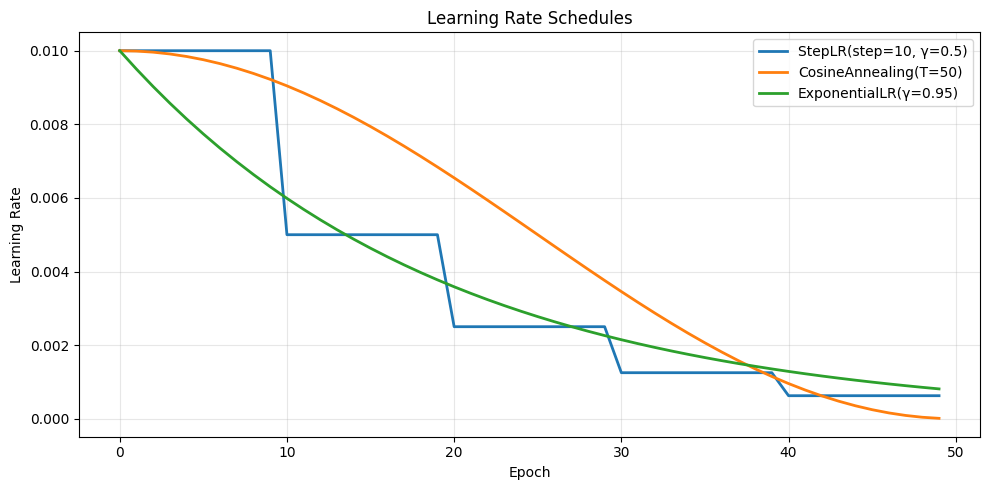

→ 圖表儲存至 plots/08_lr_schedule.png


In [6]:
print("\n" + "=" * 60)
print("4. Learning Rate Scheduling — 動態調整學習率")
print("=" * 60)

print("""
策略：
  - StepLR:      每 N 個 epoch 乘以 γ
  - CosineAnnealing: 從高到低，像餘弦曲線
  - ReduceOnPlateau: Loss 不再下降時才降低
  - Warmup + Decay: 先慢慢升，再慢慢降（Transformer 常用）
""")

model = nn.Linear(10, 3)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# 模擬不同 scheduler
schedulers = {
    'StepLR(step=10, γ=0.5)': torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5),
    'CosineAnnealing(T=50)': torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50),
    'ExponentialLR(γ=0.95)': torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95),
}

plt.figure(figsize=(10, 5))

for name, scheduler in schedulers.items():
    optimizer.param_groups[0]['lr'] = 0.01   # 重置
    lrs = []
    for epoch in range(50):
        lrs.append(optimizer.param_groups[0]['lr'])
        scheduler.step()
    plt.plot(lrs, label=name, linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedules')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('phase-2-deep-learning/plots/08_lr_schedule.png', dpi=100)
plt.show()
print("→ 圖表儲存至 plots/08_lr_schedule.png")

## 5. Gradient Clipping

In [7]:
print("\n" + "=" * 60)
print("5. Gradient Clipping — 防止梯度爆炸")
print("=" * 60)

print("""
用法：
  loss.backward()
  torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
  optimizer.step()

  → 如果梯度的 L2 norm 超過 max_norm，就等比例縮小
  → RNN / Transformer 訓練幾乎必備
""")

model = nn.Linear(10, 3)
x = torch.randn(5, 10)
y = torch.tensor([0, 1, 2, 0, 1])
loss = nn.CrossEntropyLoss()(model(x), y)
loss.backward()

# 看梯度 norm
total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
print(f"  梯度裁剪前的 norm: {total_norm:.4f}")
print(f"  裁剪到 max_norm=1.0")


5. Gradient Clipping — 防止梯度爆炸

用法：
  loss.backward()
  torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
  optimizer.step()

  → 如果梯度的 L2 norm 超過 max_norm，就等比例縮小
  → RNN / Transformer 訓練幾乎必備

  梯度裁剪前的 norm: 1.2802
  裁剪到 max_norm=1.0


## 6. Early Stopping

In [8]:
print("\n" + "=" * 60)
print("6. Early Stopping — 在最佳時刻停止訓練")
print("=" * 60)

class EarlyStopping:
    """驗證 Loss 連續 patience 個 epoch 不改善就停止"""

    def __init__(self, patience=10, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.should_stop = False

    def step(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop

# 模擬
print("模擬 Early Stopping:")
early_stop = EarlyStopping(patience=5)
fake_losses = [1.0, 0.8, 0.6, 0.5, 0.49, 0.48, 0.48, 0.49, 0.50, 0.51, 0.52, 0.53]

for epoch, loss in enumerate(fake_losses):
    stopped = early_stop.step(loss)
    status = "STOP!" if stopped else f"patience={early_stop.counter}/{early_stop.patience}"
    print(f"  Epoch {epoch:2d}: loss={loss:.2f}  {status}")
    if stopped:
        break


6. Early Stopping — 在最佳時刻停止訓練
模擬 Early Stopping:
  Epoch  0: loss=1.00  patience=0/5
  Epoch  1: loss=0.80  patience=0/5
  Epoch  2: loss=0.60  patience=0/5
  Epoch  3: loss=0.50  patience=0/5
  Epoch  4: loss=0.49  patience=0/5
  Epoch  5: loss=0.48  patience=0/5
  Epoch  6: loss=0.48  patience=1/5
  Epoch  7: loss=0.49  patience=2/5
  Epoch  8: loss=0.50  patience=3/5
  Epoch  9: loss=0.51  patience=4/5
  Epoch 10: loss=0.52  STOP!


## 7. 整合：帶所有技巧的完整模型

In [9]:
print("\n" + "=" * 60)
print("7. 整合：帶所有技巧的完整模型")
print("=" * 60)

class RobustClassifier(nn.Module):
    """包含 BN + Dropout + 正確初始化的分類器"""

    def __init__(self, input_dim, hidden_dim, num_classes, dropout_p=0.3):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),       # BN 在激活前
            nn.ReLU(),
            nn.Dropout(dropout_p),             # Dropout 在激活後

            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(hidden_dim, num_classes),
        )

        # Kaiming 初始化
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


# 訓練
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

digits = load_digits()
scaler = StandardScaler()
X = torch.tensor(scaler.fit_transform(digits.data), dtype=torch.float32)
y = torch.tensor(digits.target, dtype=torch.long)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_te, y_te), batch_size=32)

model = RobustClassifier(64, 128, 10, dropout_p=0.3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
early_stop = EarlyStopping(patience=15)

print(f"模型:\n{model}\n")
print(f"{'Epoch':>5} {'Train':>8} {'Val':>8} {'LR':>10}")
print("-" * 34)

for epoch in range(1, 101):
    # Train
    model.train()
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        loss = criterion(model(bx), by)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

    scheduler.step()

    # Eval
    model.eval()
    with torch.no_grad():
        train_acc = (model(X_tr.to(device)).argmax(1) == y_tr.to(device)).float().mean()
        val_acc = (model(X_te.to(device)).argmax(1) == y_te.to(device)).float().mean()
        val_loss = criterion(model(X_te.to(device)), y_te.to(device))

    if epoch % 10 == 0 or epoch == 1:
        lr = optimizer.param_groups[0]['lr']
        print(f"{epoch:5d} {train_acc:8.2%} {val_acc:8.2%} {lr:10.6f}")

    if early_stop.step(val_loss.item()):
        print(f"  → Early Stopping at epoch {epoch}")
        break

print(f"\n最終 Test Accuracy: {val_acc:.2%}")


7. 整合：帶所有技巧的完整模型


模型:
RobustClassifier(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=10, bias=True)
  )
)

Epoch    Train      Val         LR
----------------------------------


    1   83.44%   84.72%   0.000999


   10   99.51%   97.78%   0.000905


   20   99.72%   98.33%   0.000655


   30   99.86%   98.89%   0.000345


   40   99.93%   98.61%   0.000095


  → Early Stopping at epoch 44

最終 Test Accuracy: 98.33%


## 小結

In [10]:
print("\n" + "=" * 60)
print("小結")
print("=" * 60)
print("""
訓練技巧的使用時機：

  技巧                何時使用                  PyTorch
  ────────────────────────────────────────────────────────
  BatchNorm          幾乎都用                  nn.BatchNorm1d/2d
  Dropout            防過擬合（小資料集）       nn.Dropout(p=0.1~0.5)
  Kaiming Init       ReLU 網路                 nn.init.kaiming_normal_
  LR Schedule        長時間訓練                CosineAnnealing / Warmup
  Gradient Clip      RNN / Transformer         clip_grad_norm_(max=1.0)
  Early Stopping     防過擬合                  自己寫（見上面）
  Weight Decay       正則化                    AdamW(weight_decay=0.01)

典型組合（現代模型）：
  AdamW + CosineAnnealing + Warmup + Gradient Clip + BN/LayerNorm

═══════════════════════════════════════════
  Phase 2 完成！
  你現在能用 PyTorch 訓練神經網路了。
  下一步：Phase 3 — 訓練實務（GPU、混合精度、分散式）
  或：Phase 4 — 選一個領域深入（CV / NLP）
═══════════════════════════════════════════
""")


小結

訓練技巧的使用時機：

  技巧                何時使用                  PyTorch
  ────────────────────────────────────────────────────────
  BatchNorm          幾乎都用                  nn.BatchNorm1d/2d
  Dropout            防過擬合（小資料集）       nn.Dropout(p=0.1~0.5)
  Kaiming Init       ReLU 網路                 nn.init.kaiming_normal_
  LR Schedule        長時間訓練                CosineAnnealing / Warmup
  Gradient Clip      RNN / Transformer         clip_grad_norm_(max=1.0)
  Early Stopping     防過擬合                  自己寫（見上面）
  Weight Decay       正則化                    AdamW(weight_decay=0.01)

典型組合（現代模型）：
  AdamW + CosineAnnealing + Warmup + Gradient Clip + BN/LayerNorm

═══════════════════════════════════════════
  Phase 2 完成！
  你現在能用 PyTorch 訓練神經網路了。
  下一步：Phase 3 — 訓練實務（GPU、混合精度、分散式）
  或：Phase 4 — 選一個領域深入（CV / NLP）
═══════════════════════════════════════════

